In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

In [4]:
df = pd.read_csv("merged.csv", low_memory=False)
df['Date'] = pd.to_datetime(df['Date'])


In [5]:
df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


In [6]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [7]:
df = df.sort_index()

In [8]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [9]:
df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


<Axes: xlabel='Date'>

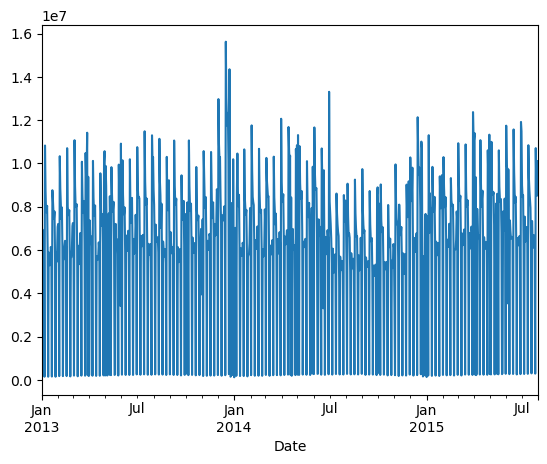

In [10]:
daily_sales = df.groupby('Date')['Sales'].sum()
daily_sales.plot()

<Axes: xlabel='Date'>

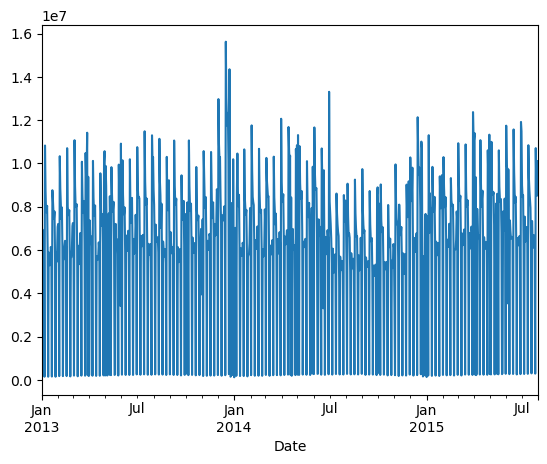

In [11]:
#data shows all store data so sifting through will help display better

df_open = df[df['Open'] == 1]
daily_sales = df_open.groupby('Date')['Sales'].sum()
daily_sales.plot()

In [12]:
df['Sales'].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [13]:
df_onlysales=df.drop(df[(df.Open == 0) & (df.Sales == 0)].index)

In [14]:
df['Sales'].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

<Axes: xlabel='Date'>

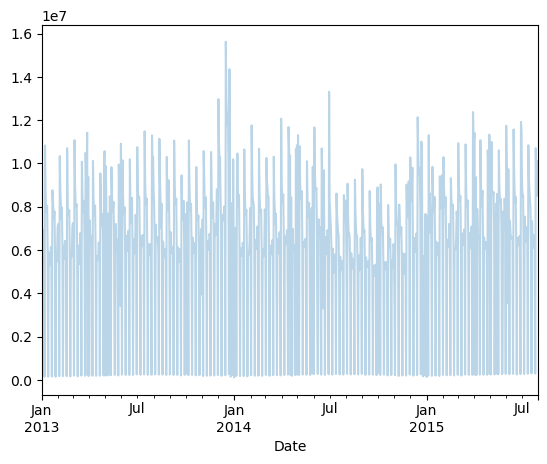

In [15]:
daily_sales = df.groupby('Date')['Sales'].sum()
daily_sales.plot(alpha=0.3)


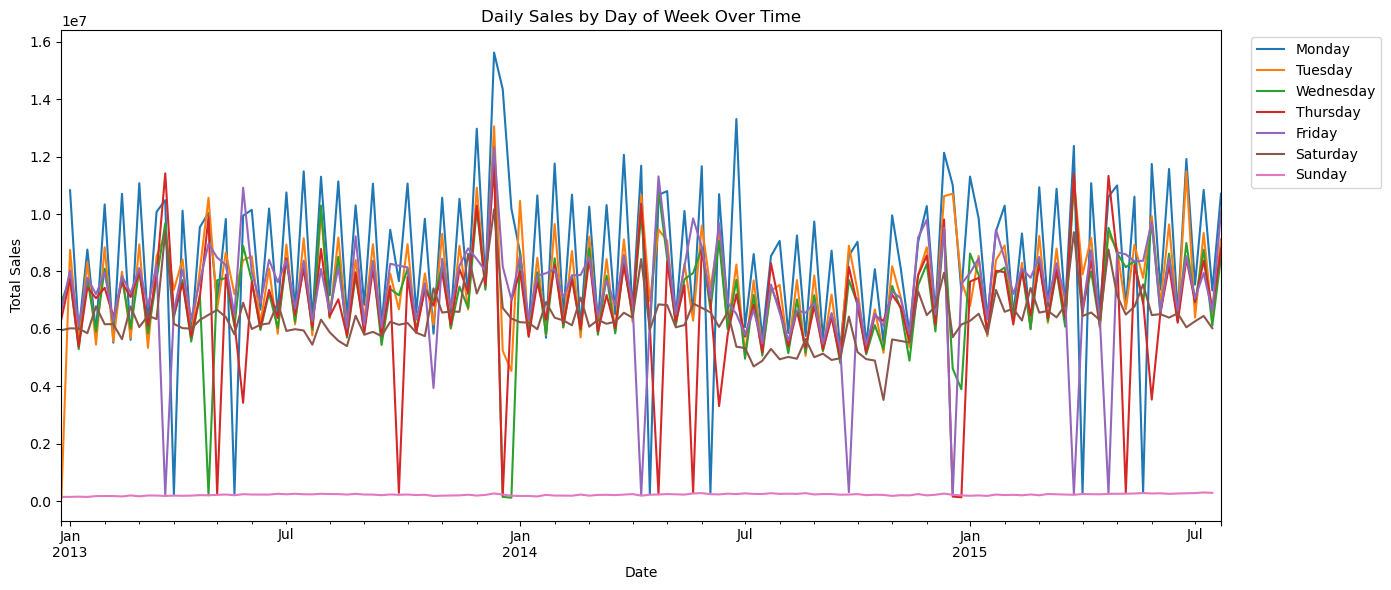

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

day_names = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday',
             5: 'Friday', 6: 'Saturday', 7: 'Sunday'}

for day_num, day_name in day_names.items():
    day_sales = df[df['DayOfWeek'] == day_num].groupby('Date')['Sales'].sum()
    day_sales.plot(ax=ax, label=day_name)

ax.set_title('Daily Sales by Day of Week Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

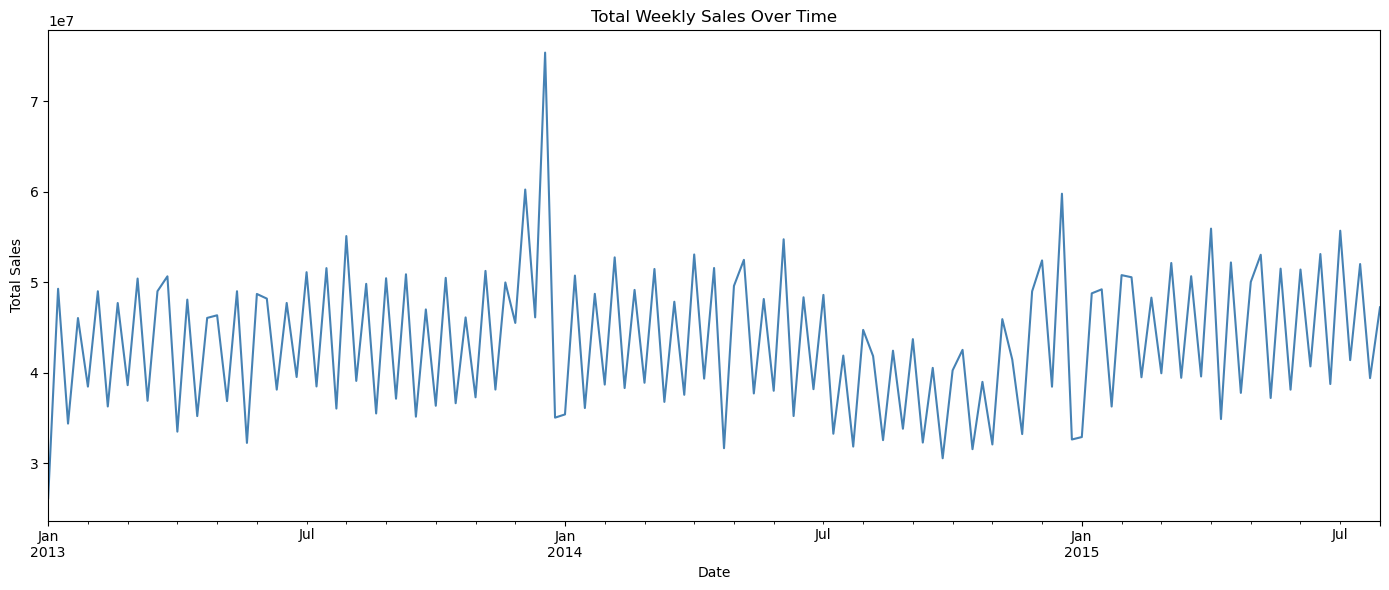

In [17]:
daily_sales = df.groupby('Date')['Sales'].sum()
daily_sales = daily_sales.asfreq('D', fill_value=0)
weekly_sales = daily_sales.resample('W').sum()

fig, ax = plt.subplots(figsize=(14, 6))
weekly_sales.plot(ax=ax, color='steelblue', linewidth=1.5)

ax.set_title('Total Weekly Sales Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [18]:
holiday_dates = df[df['StateHoliday'] != '0'][['Date', 'StateHoliday']].drop_duplicates().sort_values('Date')
print(holiday_dates)

              Date StateHoliday
1016095 2013-01-01            a
1010532 2013-01-06            a
919090  2013-03-29            b
915745  2013-04-01            b
882295  2013-05-01            a
873375  2013-05-09            a
861110  2013-05-20            a
849960  2013-05-30            a
764117  2013-08-15            a
709470  2013-10-03            a
678251  2013-10-31            a
677137  2013-11-01            a
655954  2013-11-20            a
616925  2013-12-25            c
615810  2013-12-26            c
609120  2014-01-01            a
603557  2014-01-06            a
489815  2014-04-18            b
486470  2014-04-21            b
475320  2014-05-01            a
444100  2014-05-29            a
431835  2014-06-09            a
420685  2014-06-19            a
319595  2014-10-03            a
293416  2014-10-31            a
292482  2014-11-01            a
275654  2014-11-19            a
241990  2014-12-25            c
241055  2014-12-26            c
235265  2015-01-01            a
229702  

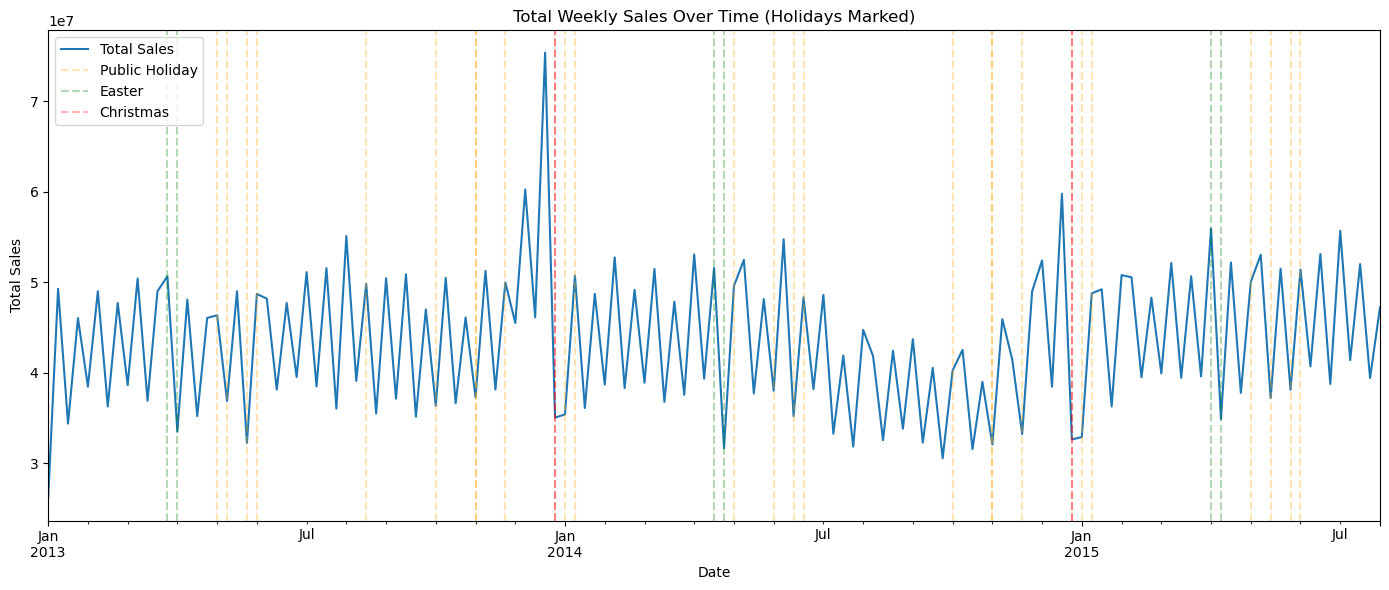

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
weekly_sales.plot(ax=ax, label='Total Sales')

colors = {'a': 'orange', 'b': 'green', 'c': 'red'}
labels_added = set()

for _, row in holiday_dates.iterrows():
    label = {'a': 'Public Holiday', 'b': 'Easter', 'c': 'Christmas'}[row['StateHoliday']]
    ax.axvline(row['Date'], color=colors[row['StateHoliday']], alpha=0.3, linestyle='--',
               label=label if label not in labels_added else None)
    labels_added.add(label)

ax.set_title('Total Weekly Sales Over Time (Holidays Marked)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
df['Store'].nunique()

1115

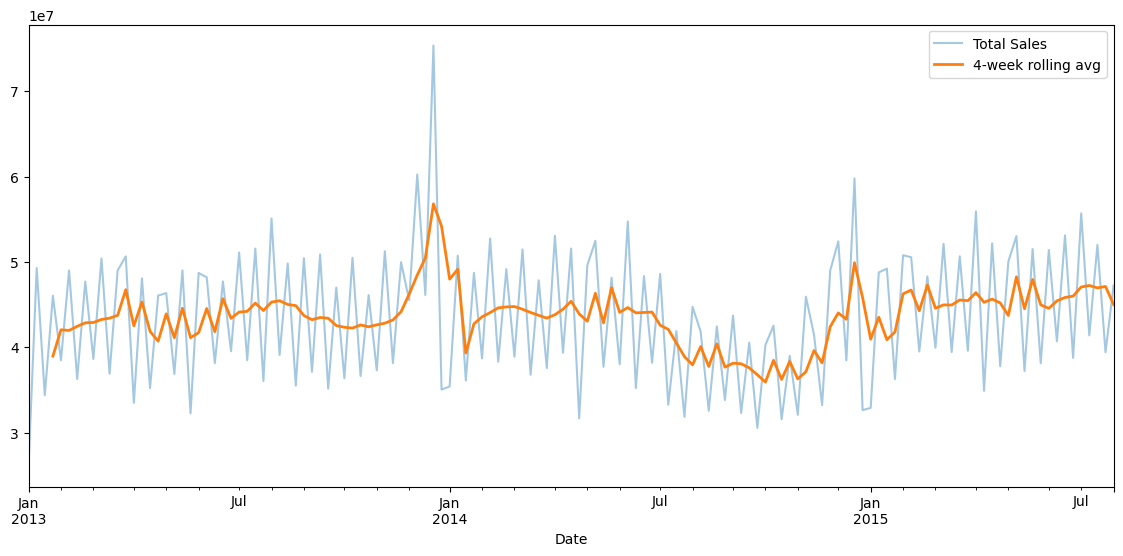

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
weekly_sales.plot(ax=ax, alpha=0.4, label='Total Sales')
weekly_sales.rolling(4).mean().plot(ax=ax, linewidth=2, label='4-week rolling avg')
ax.legend()
plt.show()

In [22]:
store_totals = df.groupby('Store')['Sales'].sum().sort_values(ascending=False)
top_20pct_cutoff = int(len(store_totals) * 0.2)
top_stores = store_totals.head(top_20pct_cutoff).index

df_top = df[df['Store'].isin(top_stores)]
df_top = df[df['Store'].isin(top_stores)].copy()
print(df_top['Store'].nunique())  

223


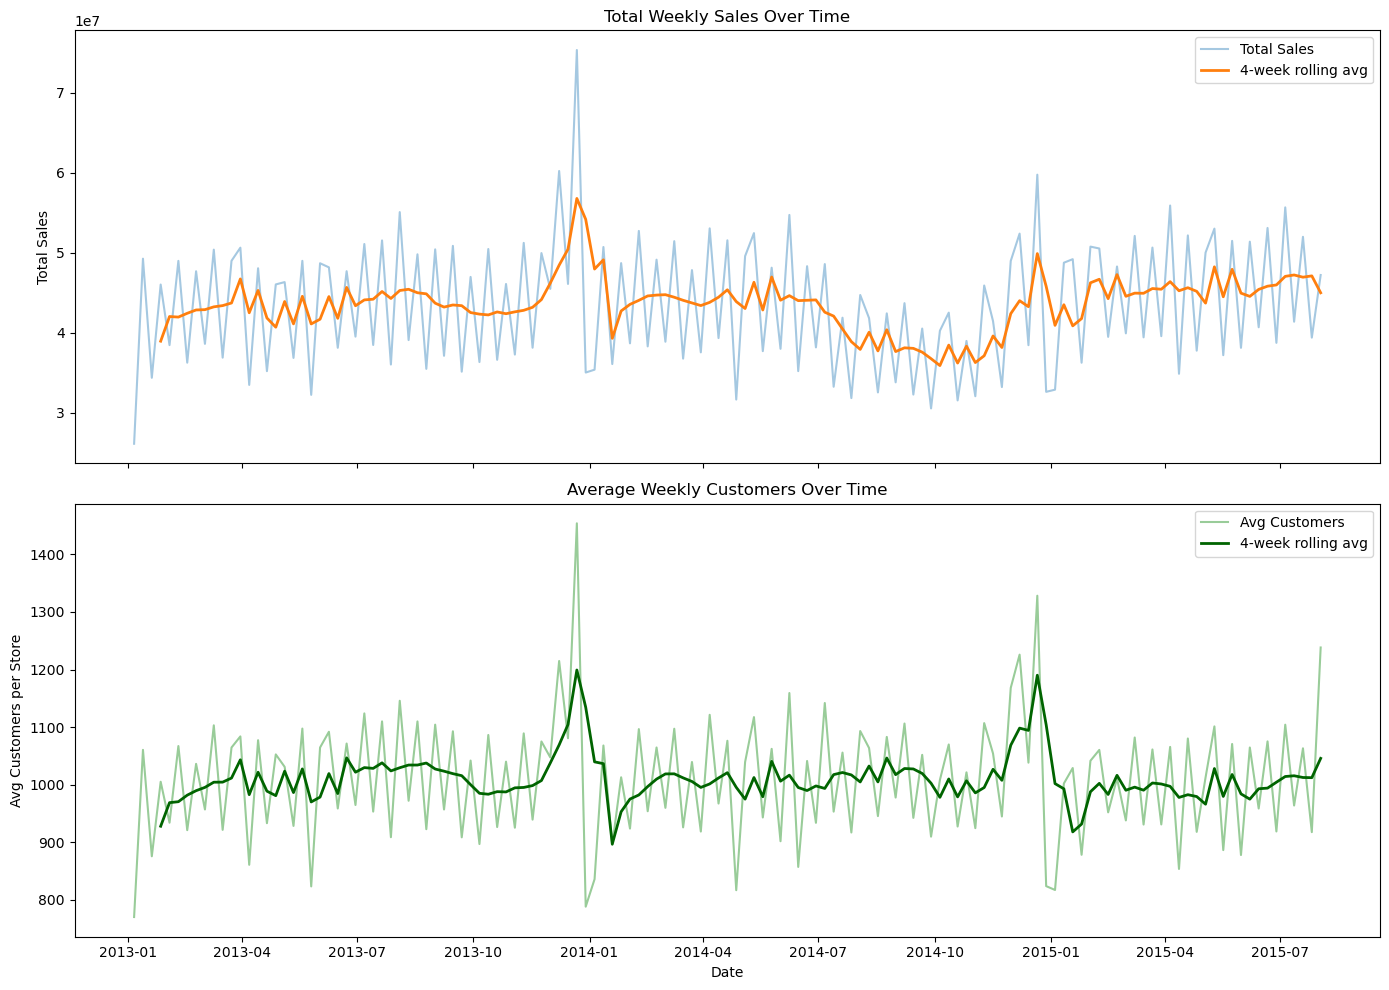

In [23]:
#average customers and sales over a time period 
daily_sales = df.groupby('Date')['Sales'].sum()
daily_sales = daily_sales.asfreq('D', fill_value=0)
weekly_sales = daily_sales.resample('W').sum()

daily_customers = df_top.groupby('Date')['Customers'].mean()
daily_customers = daily_customers.asfreq('D', fill_value=0)
weekly_customers = daily_customers.resample('W').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(weekly_sales.index, weekly_sales, alpha=0.4, label='Total Sales')
axes[0].plot(weekly_sales.index, weekly_sales.rolling(4).mean(), linewidth=2, label='4-week rolling avg')
axes[0].set_title('Total Weekly Sales Over Time')
axes[0].set_ylabel('Total Sales')
axes[0].legend()


axes[1].plot(weekly_customers.index, weekly_customers, alpha=0.4, color='green', label='Avg Customers')
axes[1].plot(weekly_customers.index, weekly_customers.rolling(4).mean(), linewidth=2, color='darkgreen', label='4-week rolling avg')
axes[1].set_title('Average Weekly Customers Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Avg Customers per Store')
axes[1].legend()

plt.tight_layout()
plt.show()



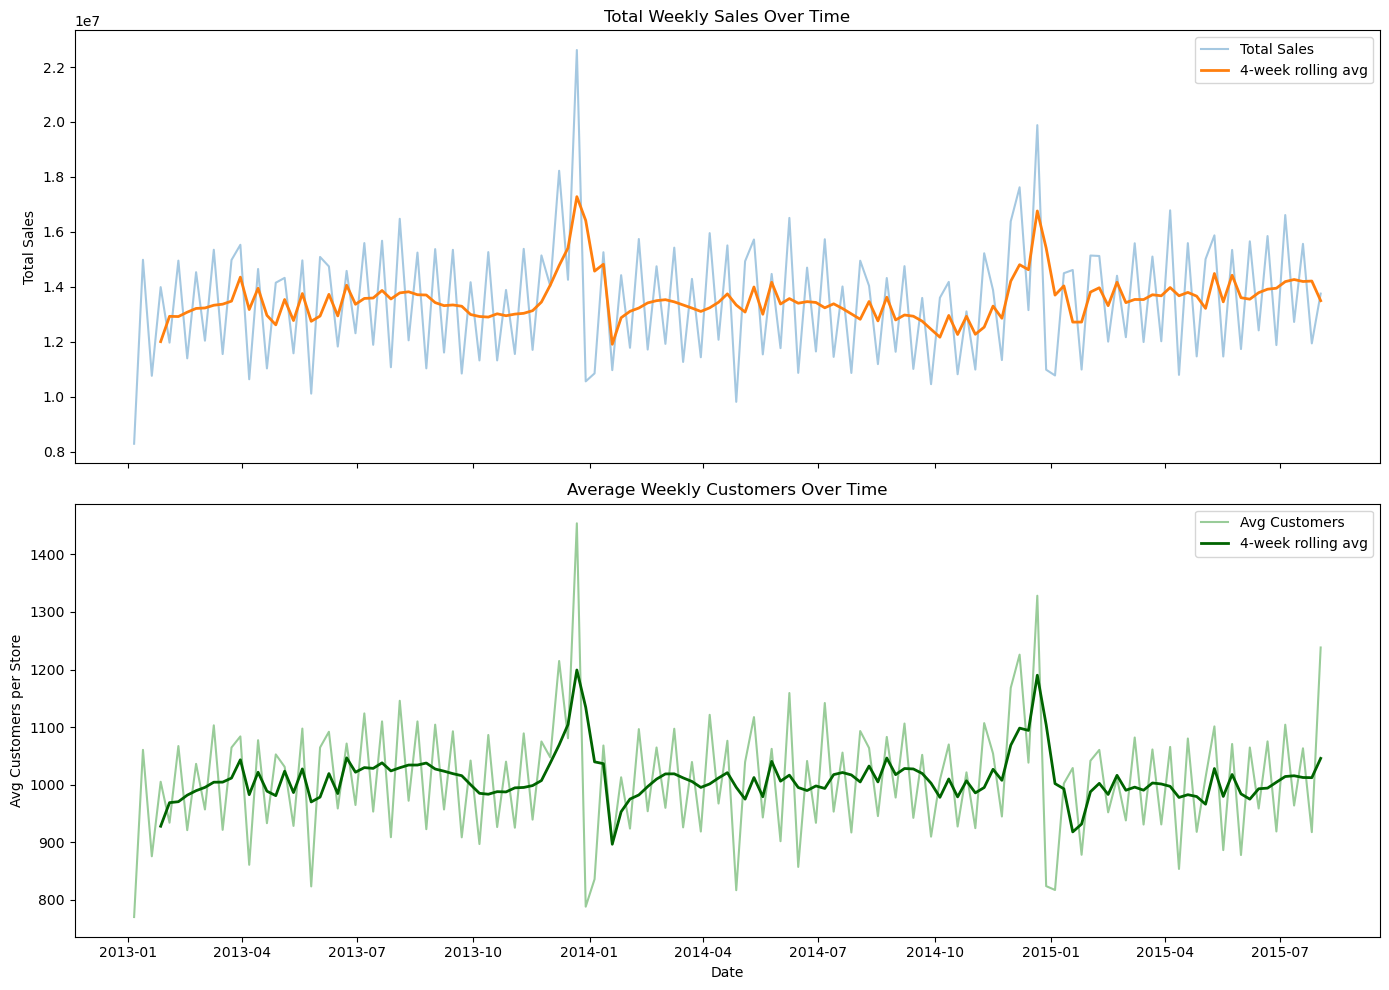

In [24]:
#now top 20% of stores 
daily_sales = df_top.groupby('Date')['Sales'].sum() 
daily_sales = daily_sales.asfreq('D', fill_value=0)
weekly_sales = daily_sales.resample('W').sum()

daily_customers = df_top.groupby('Date')['Customers'].mean()
daily_customers = daily_customers.asfreq('D', fill_value=0)
weekly_customers = daily_customers.resample('W').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(weekly_sales.index, weekly_sales, alpha=0.4, label='Total Sales')
axes[0].plot(weekly_sales.index, weekly_sales.rolling(4).mean(), linewidth=2, label='4-week rolling avg')
axes[0].set_title('Total Weekly Sales Over Time')
axes[0].set_ylabel('Total Sales')
axes[0].legend()


axes[1].plot(weekly_customers.index, weekly_customers, alpha=0.4, color='green', label='Avg Customers')
axes[1].plot(weekly_customers.index, weekly_customers.rolling(4).mean(), linewidth=2, color='darkgreen', label='4-week rolling avg')
axes[1].set_title('Average Weekly Customers Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Avg Customers per Store')
axes[1].legend()

plt.tight_layout()
plt.show()

<Axes: xlabel='Date'>

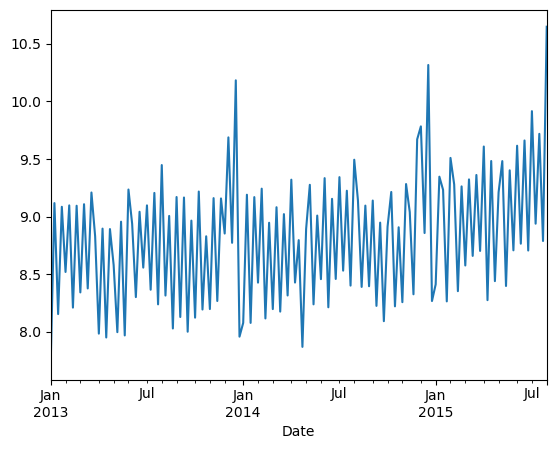

In [25]:
#very suprisingly the customer footrate wasnt increasing more decreasing especially in comaparsion to the increasing sales amounts,
#this tells us that customers must be spending more and shopping less 
df_top['SalesPerCustomer'] = df_top['Sales'] / df_top['Customers']
weekly_spc = df_top.groupby('Date')['SalesPerCustomer'].mean().asfreq('D', fill_value=None).resample('W').mean()
weekly_spc.plot()

In [26]:
df_top['Year'] = df_top['Date'].dt.year
df_top.groupby('Year')['SalesPerCustomer'].mean()
#displaying the rate of change in the sales per customer

Year
2013    9.137415
2014    9.235592
2015    9.551627
Name: SalesPerCustomer, dtype: float64

In [27]:
df_top.groupby(['Year', 'Promo'])['SalesPerCustomer'].mean()
#to see how much effet promo has on the rate of change
#it does however the rate of change is still increasing through each year 

Year  Promo
2013  0         8.650257
      1         9.780367
2014  0         8.694688
      1         9.913649
2015  0         8.971502
      1        10.224621
Name: SalesPerCustomer, dtype: float64

In [41]:
df_top['Month']=df_top.Date.dt.month
df_top['Year']=df_top.Date.dt.year
df_top.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,SalesPerCustomer,Year,Month
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,620.0,9.0,2009.0,0,NaN,NaN,NaN,9.342457,2015,7
6,7,5,2015-07-31,15344,1414,1,1,0,1,a,...,24000.0,4.0,2013.0,0,NaN,NaN,NaN,10.851485,2015,7
23,24,5,2015-07-31,14190,1082,1,1,0,1,a,...,4590.0,3.0,2000.0,1,40.0,2011.0,"Jan,Apr,Jul,Oct",13.114603,2015,7
24,25,5,2015-07-31,14180,1586,1,1,0,1,c,...,430.0,4.0,2003.0,0,NaN,NaN,NaN,8.940731,2015,7
26,27,5,2015-07-31,13213,1263,1,1,0,1,a,...,60.0,1.0,2005.0,1,5.0,2011.0,"Jan,Apr,Jul,Oct",10.461599,2015,7


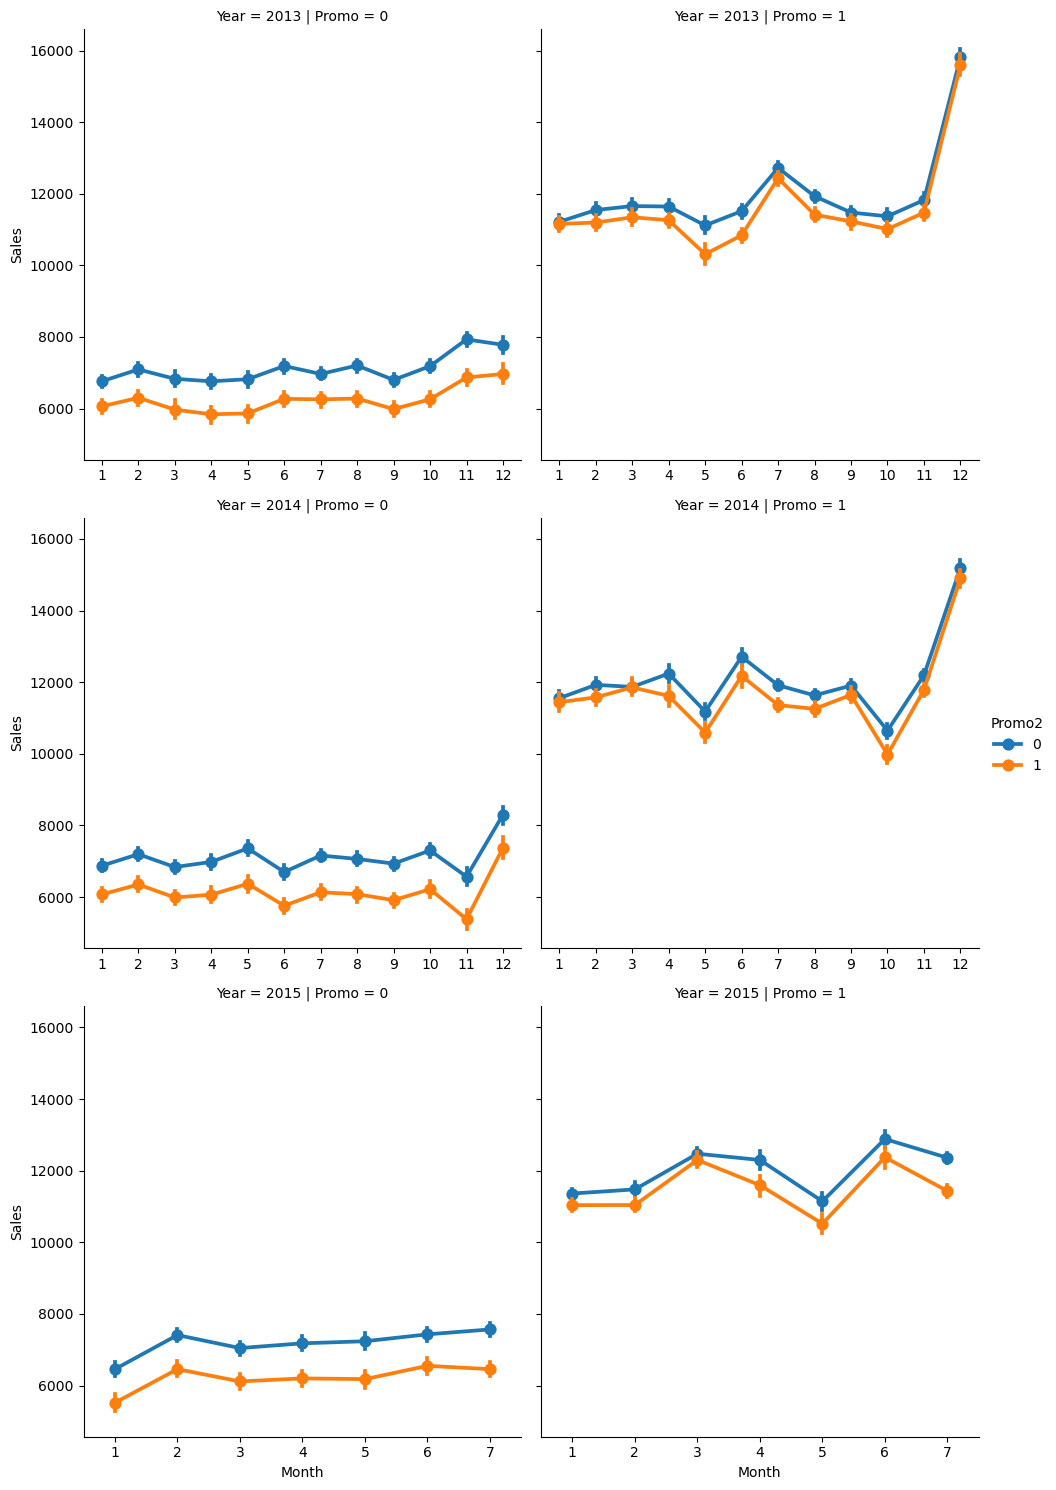

In [40]:
sns.catplot(df_top, x ="Month", y = "Sales", 
               col = 'Promo', # per store type in cols
               hue = 'Promo2',
               row = "Year",
            sharex=False,
            kind="point")

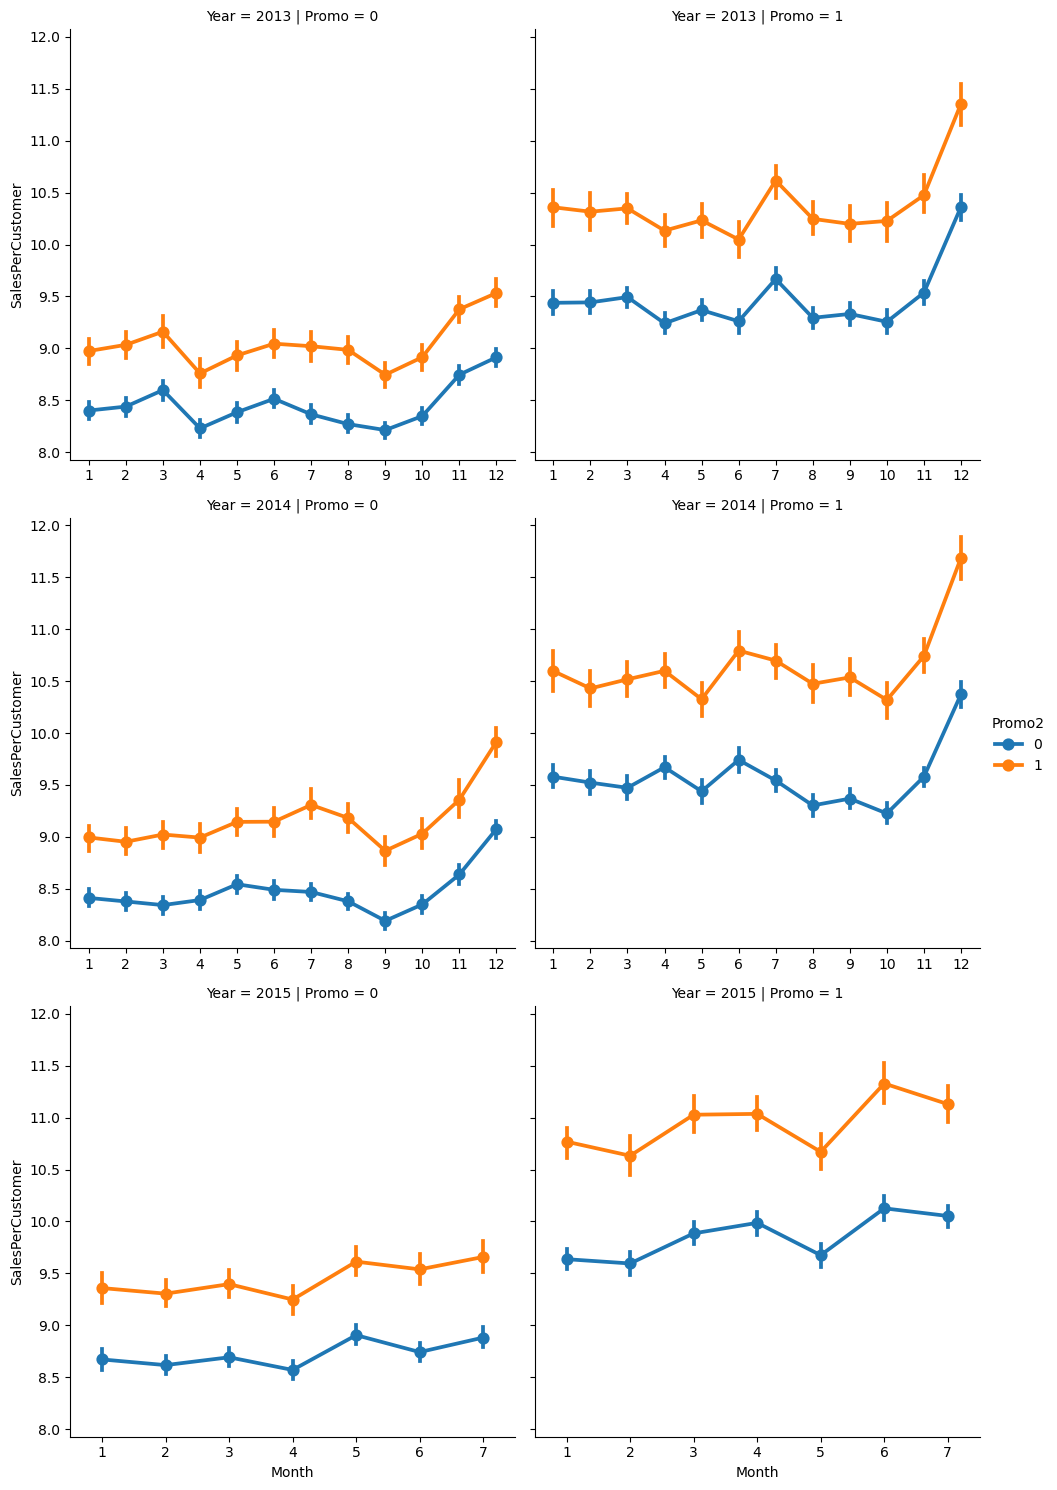

In [43]:
sns.catplot(df_top, x ="Month", y = "SalesPerCustomer", 
               col = 'Promo', # per store type in cols
               hue = 'Promo2',
               row = "Year",
            sharex=False,
           kind="point")